**Input:**
- process sensor readings
- equipment parameters
- pass/fail labels
- simulated defect logs
- simulated corrective action history

**Tasks:**
1. load CSV data
2. clean missing values
3. normalize sensor features
4. split train/test data

**Output:**
- clean manufacturing dataset

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_csv('secom/secom_labels.data', sep=r'\s+', header=None)
df1 = df1.rename(columns={0: 'class', 1: 'time'})
df1.head()

,class,time
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00


In [3]:
df2 = pd.read_csv('secom/secom.data', sep=r'\s+', header=None)
df2.columns = [f'sensor_{i}' for i in range(df2.shape[1])]
df2.head()

,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_580,sensor_581,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [4]:
df3 = pd.concat([df1, df2], axis=1)
df3.head()

,class,time,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,...,sensor_580,sensor_581,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589
0,-1,19/07/2008 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,-1,19/07/2008 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,1,19/07/2008 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,-1,19/07/2008 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,-1,19/07/2008 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [5]:
# Data inspection
df3.shape
df3.info()
df3.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, class to sensor_589
dtypes: float64(590), int64(1), str(1)
memory usage: 7.1 MB


class          0
time           0
sensor_0       6
sensor_1       7
sensor_2      14
              ..
sensor_585     1
sensor_586     1
sensor_587     1
sensor_588     1
sensor_589     1
Length: 592, dtype: int64

In [6]:
print(f'Total missing cells: {df3.isna().sum().sum()}')
print(f'Total cells: {df3.size}')
print(f'Percentage of missing values in dataframe: {df3.isna().sum().sum() / df3.size * 100:.2f}%')

Total missing cells: 41951
Total cells: 927664
Percentage of missing values in dataframe: 4.52%


In [7]:
print(f'Max number of missing values from a feature: {df3.isna().sum().max()}')

Max number of missing values from a feature: 1429


In [8]:
# Handling missing values
missing_pct = df3.isna().mean() * 100
missing_pct.sort_values(ascending=False)

sensor_292    91.193363
sensor_158    91.193363
sensor_157    91.193363
sensor_293    91.193363
sensor_358    85.577537
                ...    
sensor_248     0.000000
sensor_249     0.000000
sensor_250     0.000000
sensor_251     0.000000
class          0.000000
Length: 592, dtype: float64

In [9]:
# Drop columns with too much missing values
# 1. Find threshold value to drop column
print(f'Number of columns with missing values > 50%: {missing_pct[missing_pct > 50].count()}')

Number of columns with missing values > 50%: 28


Important notes:
- Missingness mean a sensor is offline, inactive, or not measured for many lots.
- ~ 50% means half of the values would be imputed.  
- To get a proper threshold, inspect the distribution and check for a natural gap in the missingness distribution. 

In [10]:
missing_pct.describe()

count    592.000000
mean       4.522219
std       15.410102
min        0.000000
25%        0.127632
50%        0.382897
75%        0.574346
max       91.193363
dtype: float64

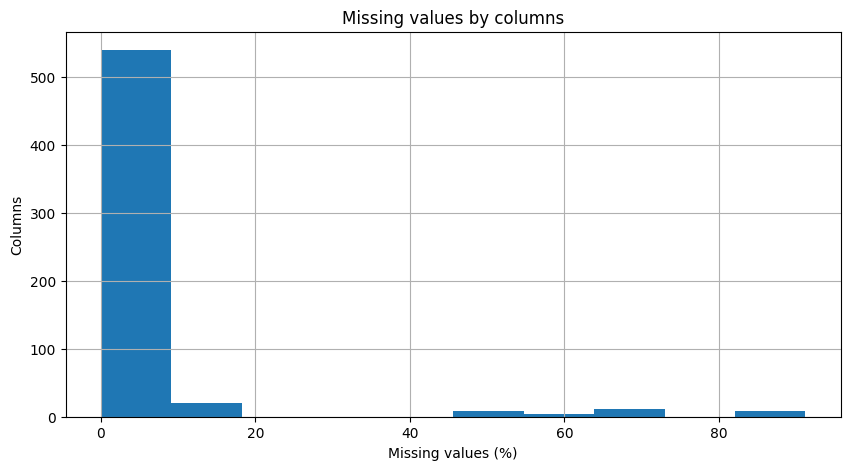

In [13]:
plt.figure(figsize=(10, 5))
missing_pct.hist(bins=10)
plt.title('Missing values by columns')
plt.xlabel('Missing values (%)')
plt.ylabel('Columns')
plt.show()

From figure:
- Most columns have less than 20% missing values.
- Few missing values then jumps above 40%. 

In [14]:
# Compare thresholds
for threshold in [20, 30, 40, 50, 60]:
    cols_dropped = (missing_pct > threshold).sum()
    cols_kept = df3.shape[1] - cols_dropped
    print(f'Threshold: {threshold} | Drop: {cols_dropped}, Keep: {cols_kept}')

Threshold: 20 | Drop: 32, Keep: 560
Threshold: 30 | Drop: 32, Keep: 560
Threshold: 40 | Drop: 32, Keep: 560
Threshold: 50 | Drop: 28, Keep: 564
Threshold: 60 | Drop: 24, Keep: 568


- Threshold 20, 30, 40 have the same dropped columns.
- Meaning, dataset has a gap where 32 columns are already above 40% missing, and the rest are below 20%.
- Choosing 40% gave good balance, removes the 32 weakest columns while keeping 560 columns. 

In [15]:
# Use 40% threshold to drop columns with missing values
cols_to_drop = missing_pct[missing_pct > 40].index
df3_clean = df3.drop(columns=cols_to_drop)
df3_clean.shape

(1567, 560)

In [16]:
# Cleaning data types
print(df3_clean['time'].dtype)

str


In [17]:
# Convert 'Time' column into the right dtype
df3_clean['time'] = pd.to_datetime(df3_clean['time'], dayfirst=True, errors='coerce')
print(df3_clean['time'].dtype)
df3_clean.head()

datetime64[us]


,class,time,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,...,sensor_576,sensor_577,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589
0,-1,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,...,1.6765,14.9509,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,-1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,...,1.1065,10.9003,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,1,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,...,2.0952,9.2721,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,-1,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,...,1.7585,8.5831,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,-1,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,...,1.6597,10.9698,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [18]:
df3_clean['time'].isna().sum()

np.int64(0)

In [19]:
df3_clean['time'].min(), df3_clean['time'].max() 

(Timestamp('2008-07-19 11:55:00'), Timestamp('2008-10-17 06:07:00'))

In [21]:
# Checking class diversity
df3_clean['class'].unique()

array([-1,  1])

- '-1' represent fail
- '1' represent pass

In [22]:
df3_clean['class'].value_counts()

class
-1    1463
 1     104
Name: count, dtype: int64

- Dataset has 1567 entries, 560 features and 104 failed test. 
- This makes the dataset extremely imbalance.

In [23]:
# Remove constant sensors
# These sensors cannot help explain pass/fail difference
sensor_cols = df3_clean.columns.difference(['class', 'time'])       # Find columns in df3_clean excluding the list
low_info_cols = [col for col in sensor_cols if df3_clean[col].nunique(dropna=True) <= 1]

df3_clean = df3_clean.drop(columns=low_info_cols)
len(low_info_cols)

116

- If every row has the same value, that sensor cannot explain why one product passed and another failed (no insights).

In [29]:
# Fill missing values using median
sensor_cols = df3_clean.columns.difference(['class', 'time'])  
df3_clean[sensor_cols] = df3_clean[sensor_cols].fillna(df3_clean[sensor_cols].median())

In [30]:
df3_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 444 entries, class to sensor_589
dtypes: datetime64[us](1), float64(442), int64(1)
memory usage: 5.3 MB


In [36]:
print('Data Cleaning Summary')
print('---------------------')
print(f'Original features: {df3.shape[1]}')
print(f'Clean features: {df3_clean.shape[1]}')
print(f'Features removed: {df3.shape[1] - df3_clean.shape[1]}')
print(f'Null values: {df3_clean.isnull().sum().sum()}')

# Export dataset to csv
df3_clean.to_csv('processed/cleaned_secom.csv', index=False)
print('Clean dataset exported successfully.')


Data Cleaning Summary
---------------------
Original features: 592
Clean features: 444
Features removed: 148
Null values: 0
Clean dataset exported successfully.
